In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
import pandas as pd
import numpy as np

# Method 1: Using pandas (recommended - easiest to work with)
def load_with_pandas(filepath):
    """
    Load the .dat file using pandas
    Returns a DataFrame with column names and data
    """
    df = pd.read_csv(filepath, sep=r'\s+')
    return df

# Method 2: Using numpy
def load_with_numpy(filepath):
    """
    Load the .dat file using numpy
    Returns a structured array or regular array
    Note: This file has variable columns per row, so we'll use pandas internally
    """
    # For this file with varying columns, pandas handles it better
    # But we can convert to numpy array
    import pandas as pd
    df = pd.read_csv(filepath, sep=r'\s+')
    
    # Convert to numpy array
    data = df.values
    headers = df.columns.tolist()
    
    return data, headers

In [3]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

### Parameters

In [4]:
fname = '../../../../../Data/Animal_Trajectory_Data/cockroach/wind100/laminar/23april09i.dat'
df = load_with_pandas(fname)

flow_direction = 0
flow_condition = 'laminar'
flow_speed = 1
body_length = 0.04
locomotion = 'walking'
medium = 'air'
group = 'terrestrial'

interp_dt = 0.01

### Get time stamps and speed -- this is custom per data type

In [5]:
df_calibrated = df[['x', 'y']].copy()
df_calibrated.x /= 100
df_calibrated.y /= 100

df_calibrated['timestamps_sec'] = df.time

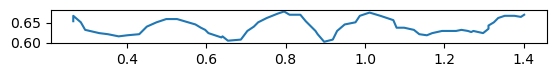

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.set_aspect('equal')

In [7]:
df_calibrated.x

0     1.40131
1     1.39313
2     1.37677
3     1.36587
4     1.35224
       ...   
62    0.32988
63    0.29444
64    0.28353
65    0.26445
66    0.26445
Name: x, Length: 67, dtype: float64

### Interpolate

In [8]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), interp_dt)

spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=1e-4, k=1)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=1e-4, k=1)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

### Parameters

In [9]:
df_calibrated_interp.shape

(550, 3)

In [10]:
tix_start = 100
tix_end = 549

1.0


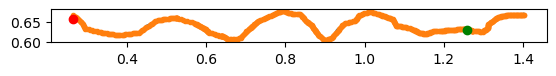

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [12]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [13]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

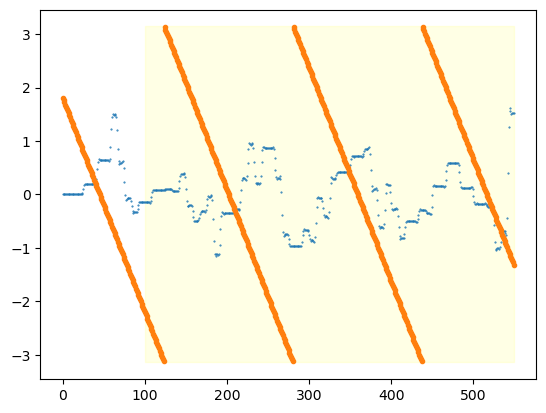

In [14]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.04
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [15]:
min_ix_range = 200
max_ix_range = 250

In [16]:
trajec = df_calibrated_interp

In [17]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [18]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)

trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

# Note

Because the amplitude is so small I constrain the slope. I found the constrained slope range by first amplifying the course direction by a factor of 1.5

In [19]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=1.5,
                                                  large_error_penalty=0.5,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,
                                                  slope_min=0.02,
                                                  slope_max=0.1,
                                                  affine_huber_M=0.1,
                                                 )

Restricted license - for non-production use only - expires 2027-11-29


SolverError: Solver 'GUROBI' failed. Try another solver, or solve with verbose=True for more information.

In [42]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix,iteration,obj_id_unique_event,timestep_sec
4,295,519,0.047452,3.608702,-1.637145,0.537993,0.000985,0.003345,0.035525,0.035525,...,0.910232,-3.194864e-02,0.828591,-0.032919,0.001830,0.266459,322,4,wind100/laminar/23april09i,0.01
7,336,543,0.020000,-2.779200,-4.724262,0.164742,-0.075084,0.075050,-0.002847,-0.002847,...,0.869034,7.295481e-07,0.275364,-0.038669,0.455765,0.473668,454,7,wind100/laminar/23april09i,0.01
6,321,545,0.020000,-2.870203,1.475755,0.172570,-0.049064,0.047068,-0.020938,-0.020938,...,0.887908,2.310336e-02,0.238495,-0.049351,0.284313,0.490107,458,6,wind100/laminar/23april09i,0.01
2,326,540,0.099871,4.726892,1.899846,0.269377,0.035580,0.059993,-0.071497,-0.071497,...,0.902747,9.810394e-02,0.081958,-0.114882,0.132081,0.529544,331,2,wind100/laminar/23april09i,0.01
3,105,334,0.030784,-3.613064,-4.281786,0.163428,-0.086092,0.042616,0.094646,0.094646,...,0.878000,-1.039795e-01,-0.145968,-0.018443,0.526787,0.562537,118,3,wind100/laminar/23april09i,0.01
9,110,341,0.020000,-4.121115,4.163930,0.235277,-0.024479,-0.046130,-0.115566,-0.115566,...,0.900566,-1.200493e-01,0.042325,0.082699,0.104045,0.564925,207,9,wind100/laminar/23april09i,0.01
5,108,339,0.031393,-3.828811,-4.337525,0.185565,-0.081642,0.045820,0.091043,0.091043,...,0.875160,-8.519853e-02,-0.119719,-0.026095,0.439964,0.568838,122,5,wind100/laminar/23april09i,0.01
8,237,466,0.020132,-0.233788,2.217022,0.164994,-0.036379,-0.036642,0.096811,0.096811,...,0.835750,-9.361165e-02,-0.002986,0.026518,0.220488,0.585795,324,8,wind100/laminar/23april09i,0.01
1,146,348,0.020000,-0.186571,-3.770430,0.127281,-0.094125,-0.050678,0.105320,0.105320,...,0.908036,-1.600677e-01,-0.053339,0.055459,0.739509,0.589969,324,1,wind100/laminar/23april09i,0.01
0,200,400,0.020473,-0.378686,1.283456,0.120057,-0.106339,-0.088155,0.061531,0.061531,...,0.886890,1.297183e-01,0.054831,-0.096692,0.885733,0.616617,326,0,wind100/laminar/23april09i,0.01


In [43]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length

unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [44]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [45]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
4,295,519,0.047452,3.608702,-1.637145,0.537993,0.000985,0.003345,0.035525,0.035525,...,4,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
7,336,543,0.020000,-2.779200,-4.724262,0.164742,-0.075084,0.075050,-0.002847,-0.002847,...,7,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
6,321,545,0.020000,-2.870203,1.475755,0.172570,-0.049064,0.047068,-0.020938,-0.020938,...,6,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
2,326,540,0.099871,4.726892,1.899846,0.269377,0.035580,0.059993,-0.071497,-0.071497,...,2,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
3,105,334,0.030784,-3.613064,-4.281786,0.163428,-0.086092,0.042616,0.094646,0.094646,...,3,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
9,110,341,0.020000,-4.121115,4.163930,0.235277,-0.024479,-0.046130,-0.115566,-0.115566,...,9,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
5,108,339,0.031393,-3.828811,-4.337525,0.185565,-0.081642,0.045820,0.091043,0.091043,...,5,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
8,237,466,0.020132,-0.233788,2.217022,0.164994,-0.036379,-0.036642,0.096811,0.096811,...,8,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
1,146,348,0.020000,-0.186571,-3.770430,0.127281,-0.094125,-0.050678,0.105320,0.105320,...,1,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
0,200,400,0.020473,-0.378686,1.283456,0.120057,-0.106339,-0.088155,0.061531,0.061531,...,0,wind100/laminar/23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial


In [46]:
ix_all, course, linear_fit_angle, affine_fit_angle, shift_ix_adj = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

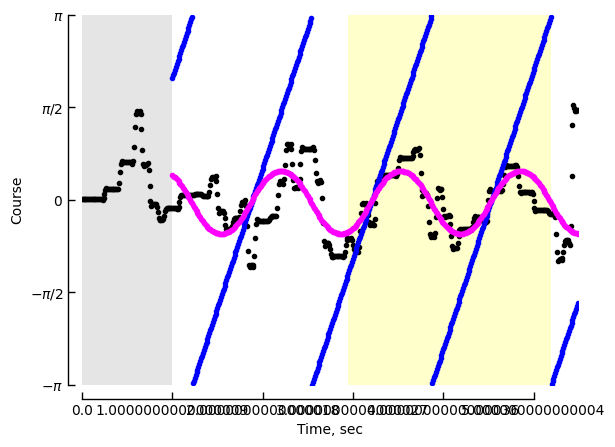

In [47]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [48]:
fname = fname.split('/')[-1]
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')

In [50]:
fname_trajec

'../../../../../Data/Animal_Trajectory_Data/cockroach/23april09i_trajec.parquet'

In [54]:
trajec['obj_id_unique_event'] = fname_trajec.split('_')[0]
unifying_algo_fit['obj_id_unique_event'] = fname_trajec.split('_')[0]

In [55]:
unifying_algo_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
0,200,400,0.020473,-0.378686,1.283456,0.120057,-0.106339,-0.088155,0.061531,0.061531,...,0,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
1,146,348,0.020000,-0.186571,-3.770430,0.127281,-0.094125,-0.050678,0.105320,0.105320,...,1,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
2,326,540,0.099871,4.726892,1.899846,0.269377,0.035580,0.059993,-0.071497,-0.071497,...,2,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
3,105,334,0.030784,-3.613064,-4.281786,0.163428,-0.086092,0.042616,0.094646,0.094646,...,3,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
4,295,519,0.047452,3.608702,-1.637145,0.537993,0.000985,0.003345,0.035525,0.035525,...,4,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
5,108,339,0.031393,-3.828811,-4.337525,0.185565,-0.081642,0.045820,0.091043,0.091043,...,5,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
6,321,545,0.020000,-2.870203,1.475755,0.172570,-0.049064,0.047068,-0.020938,-0.020938,...,6,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
7,336,543,0.020000,-2.779200,-4.724262,0.164742,-0.075084,0.075050,-0.002847,-0.002847,...,7,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
8,237,466,0.020132,-0.233788,2.217022,0.164994,-0.036379,-0.036642,0.096811,0.096811,...,8,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial
9,110,341,0.020000,-4.121115,4.163930,0.235277,-0.024479,-0.046130,-0.115566,-0.115566,...,9,23april09i,0.01,0,laminar,1,0.04,walking,air,terrestrial


In [56]:
trajec.to_parquet(fname_trajec)
unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')